In [2]:
import sys, pathlib
REPO_ROOT = pathlib.Path("/Users/Sbf/Desktop/to_verilate").resolve()
sys.path.insert(0, str(REPO_ROOT))

from emulator.emulator import QickEmulator
from qick import QickConfig
from qick.asm_v2 import AveragerProgramV2

CFG_PATH = REPO_ROOT / "emulator" / "qick_config_216.json"

In [ ]:
emu = QickEmulator(str(CFG_PATH)) 

# 2. Show the "BEFORE" state
print("--- Config [BEFORE] ---")
emu.print_config("gens")
emu.print_config("rf.tiles")

QICK library version mismatch: 0.2.366 remote (the board), 0.2.370 local (the PC)
                        This may cause errors, usually KeyError in QickConfig initialization.
                        If this happens, you must bring your versions in sync.


--- Config [BEFORE] ---
[
  {
    "b_dds": 32,
    "b_phase": 32,
    "complex_env": true,
    "dac": "00",
    "f_dds": 9584.64,
    "f_fabric": 599.04,
    "fdds_div": 1,
    "fs": 9584.64,
    "fs_div": 1,
    "fs_mult": 39,
    "fullpath": "axis_signal_gen_v6_0",
    "has_dds": true,
    "has_mixer": false,
    "interpolation": 1,
    "maxlen": 65536,
    "maxv": 32766,
    "maxv_scale": 1.0,
    "mixer_freq": 100.0,
    "revision": 4,
    "samps_per_clk": 16,
    "tproc_ch": 0,
    "type": "axis_signal_gen_v6",
    "version": "1.0"
  },
  {
    "b_dds": 32,
    "b_phase": 32,
    "complex_env": true,
    "dac": "01",
    "f_dds": 9584.64,
    "f_fabric": 599.04,
    "fdds_div": 1,
    "fs": 9584.64,
    "fs_div": 1,
    "fs_mult": 39,
    "fullpath": "axis_signal_gen_v6_1",
    "has_dds": true,
    "has_mixer": false,
    "interpolation": 1,
    "maxlen": 16384,
    "maxv": 32766,
    "maxv_scale": 1.0,
    "revision": 4,
    "samps_per_clk": 16,
    "tproc_ch": 1,
    "type": "ax

In [ ]:
# B) Edit JSON 
soccfg = QickConfig(str(CFG_PATH))

# Use dot-notation paths to set any value you want
emu.set_config_value("gens.0.mixer_freq", 100.0)
emu.set_config_value("rf.tiles.dac.2.fs", 5898.24)
emu.commit()                     # persist and reload QickConfig

# Show the "AFTER" state
print("--- Config [AFTER] ---")
emu.print_config("gens")
emu.print_config("rf.tiles")

QICK library version mismatch: 0.2.366 remote (the board), 0.2.370 local (the PC)
                        This may cause errors, usually KeyError in QickConfig initialization.
                        If this happens, you must bring your versions in sync.
QICK library version mismatch: 0.2.366 remote (the board), 0.2.370 local (the PC)
                        This may cause errors, usually KeyError in QickConfig initialization.
                        If this happens, you must bring your versions in sync.
QICK library version mismatch: 0.2.366 remote (the board), 0.2.370 local (the PC)
                        This may cause errors, usually KeyError in QickConfig initialization.
                        If this happens, you must bring your versions in sync.


--- Config [AFTER] ---
[
  {
    "b_dds": 32,
    "b_phase": 32,
    "complex_env": true,
    "dac": "00",
    "f_dds": 9584.64,
    "f_fabric": 599.04,
    "fdds_div": 1,
    "fs": 9584.64,
    "fs_div": 1,
    "fs_mult": 39,
    "fullpath": "axis_signal_gen_v6_0",
    "has_dds": true,
    "has_mixer": false,
    "interpolation": 1,
    "maxlen": 65536,
    "maxv": 32766,
    "maxv_scale": 1.0,
    "mixer_freq": 100.0,
    "revision": 4,
    "samps_per_clk": 16,
    "tproc_ch": 0,
    "type": "axis_signal_gen_v6",
    "version": "1.0"
  },
  {
    "b_dds": 32,
    "b_phase": 32,
    "complex_env": true,
    "dac": "01",
    "f_dds": 9584.64,
    "f_fabric": 599.04,
    "fdds_div": 1,
    "fs": 9584.64,
    "fs_div": 1,
    "fs_mult": 39,
    "fullpath": "axis_signal_gen_v6_1",
    "has_dds": true,
    "has_mixer": false,
    "interpolation": 1,
    "maxlen": 16384,
    "maxv": 32766,
    "maxv_scale": 1.0,
    "revision": 4,
    "samps_per_clk": 16,
    "tproc_ch": 1,
    "type": "axi

In [8]:
GEN_CH = 0
RO_CH = 0
TRIG_TIME = 0.40
FREQ = 100
# FREQ = 0
class MultiPulseProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        gen_ch = cfg['gen_ch']
        
        self.declare_gen(ch=gen_ch, nqz=1)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        ramp_len = self.cycles2us(20, gen_ch=gen_ch)
        self.add_gauss(ch=gen_ch, name="ramp", sigma=ramp_len/10, length=ramp_len, even_length=True)
        
        self.add_pulse(ch=gen_ch, name="myflattop", ro_ch=ro_ch, 
                       style    = "flat_top", 
                       envelope = "ramp", 
                       freq     = cfg['freq'], 
                       length   = 0.1,
                       phase    = 0,
                       gain     = 1.0, 
                      )

        self.add_pulse(ch=gen_ch, name="myflattop2", ro_ch=ro_ch, 
                       style    = "flat_top", 
                       envelope = "ramp", 
                       freq     = cfg['freq'], 
                       length   = 0.1,
                       phase    = 90,
                       gain     = 0.5, 
                      )

        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['freq'], gen_ch=gen_ch)
        # send the config to the dynamic RO
        self.send_readoutconfig(ch=ro_ch, name="myro", t=0)
        
    def _body(self, cfg):
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'], ddr4=True)

        for i in range(0,15):
            self.pulse(ch=cfg['gen_ch'], name="myflattop", t=1.0)
            self.pulse(ch=cfg['gen_ch'], name="myflattop2", t=1.0)
config = {'gen_ch': GEN_CH,
          'ro_ch': RO_CH,
          'freq': FREQ,
          'trig_time': 1.0,
          'ro_len': 5.0,
         }
prog = MultiPulseProgram(soccfg, reps=1, final_delay=0.5, cfg=config)
emu.export_pmem_hex(prog, path=REPO_ROOT/"emulator/pmem.mem")
emu.export_wmem_hex(prog, stem=str(REPO_ROOT/"emulator/wmem"))  # creates wmem_ch0.mem, wmem_ch1.mem, ...
emu.export_sgmem(prog, ch=0, prefix=str(REPO_ROOT/"emulator/sgmem_ch"))

In [ ]:
csv_path = emu.run_verilated_mem_tb(
    mem_file="stimulus.mem",            
    verilog_dir=".",
    top_module="dac_top_tb_mem",
    sources=("dac_top_tb_mem.sv","dac_top.sv","dac.sv"),
    build_dir="build_tb_mem",
    log_csv_name="top_dac_mem.csv",
    mem_filename_in_tb="stimulus.mem",
    enable_wave=False,
)

$ /opt/homebrew/bin/verilator --binary -sv -Wall -Mdir build_tb_mem --top-module dac_top_tb_mem dac_top_tb_mem.sv dac_top.sv dac.sv
make: Nothing to be done for `default'.
- V e r i l a t i o n   R e p o r t: Verilator 5.038 2025-07-08 rev UNKNOWN.REV
- Verilator: Built from 0.000 MB sources in 0 modules, into 0.000 MB in 0 C++ files needing 0.000 MB
- Verilator: Walltime 0.015 s (elab=0.000, cvt=0.000, bld=0.012); cpu 0.001 s on 1 threads
$ (cd build_tb_mem && ./Vdac_top_tb_mem)
-Info: dac_top_tb_mem.sv:63: $dumpvar ignored, as Verilated without --trace
Test completed. Data logged to top_dac_mem.csv
- dac_top_tb_mem.sv:117: Verilog $finish
- S i m u l a t i o n   R e p o r t: Verilator 5.038 2025-07-08
- Verilator: $finish at 4us; walltime 0.002 s; speed 2.185 ms/s
- Verilator: cpu 0.002 s on 1 threads; alloced 0 MB
[ok] Wrote build_tb_mem/top_dac_mem.csv


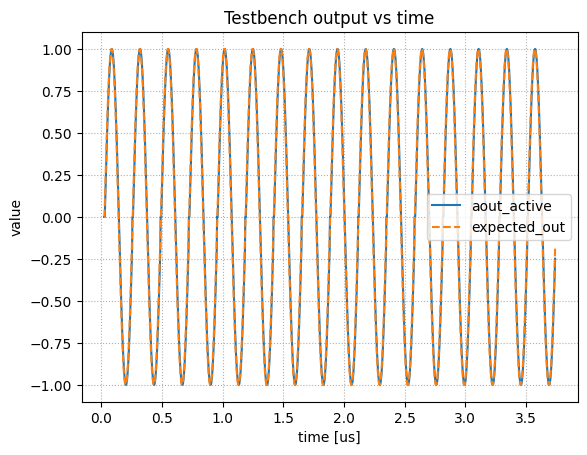

In [10]:
emu.plot_tb_csv(csv_path, value_cols=("aout_active",), expected_col="expected_out", time_unit="us")

In [6]:
prog.print_pmem2hex()

// PMEM content
000000000000000000
8c600000000000000c
dce000c20000000000
4c080000000000d700
8c6000000000000020
dda00030000000d700
dda00034800000d700
dda00035000000d700
dda00010000000dc00
dda00014800000dc00
dda00015000000dc00
dce00000000000d700
dce00020000000d700
dce00040000000d700
dce00060000000d700
dce00080000000d700
dce000a0000000d700
dce00000000000d700
dce00020000000d700
dce00040000000d700
dce00060000000d700
dce00080000000d700
dce000a0000000d700
dce00000000000d700
dce00020000000d700
dce00040000000d700
dce00060000000d700
dce00080000000d700
dce000a0000000d700
dce00000000000d700
dce00020000000d700
dce00040000000d700
dce00060000000d700
dce00080000000d700
dce000a0000000d700
dce00000000000d700
dce00020000000d700
dce00040000000d700
dce00060000000d700
dce00080000000d700
dce000a0000000d700
dce00000000000d700
dce00020000000d700
dce00040000000d700
dce00060000000d700
dce00080000000d700
dce000a0000000d700
dce00000000000d700
dce00020000000d700
dce00040000000d700
dce00060000000d700
dce00080000000d

In [ ]:
import sys, importlib, pathlib, os

REPO_ROOT = pathlib.Path("/Users/Sbf/Desktop/to_verilate").resolve()
PKG_DIR   = REPO_ROOT / "emulator"               
INIT_FILE = PKG_DIR / "__init__.py"

# Ensure __init__.py exists in PKG_DIR
if not INIT_FILE.exists():
    INIT_FILE.write_text("from .emulator import QickEmulator\n")

# Remove PKG_DIR from sys.path if it exists
sys.path = [p for p in sys.path
            if not (pathlib.Path(p).exists() and pathlib.Path(p).resolve() == PKG_DIR.resolve())]

# Ensure REPO_ROOT is in sys.path
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

# Clear any existing 'emulator' module from sys.modules and invalidate caches
sys.modules.pop("emulator", None)
importlib.invalidate_caches()

# Check that import works
from emulator.emulator import QickEmulator
print("Imported QickEmulator OK")

Imported QickEmulator OK


/Users/sbf/projects/qick-env/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
